# Лабораторная работа №6

## Условный экстремум

**Студент:** Королев А.С.  
**Группа:** ИУ5Ц-81Б  



## Цель работы

1. Исследование необходимых и достаточных условий существования экстремума функции с учетом ограничений (условный экстремум).
2. Вычисление экстремумов функции.
3. Разработка универсального программного средства для решения задач условной оптимизации.
4. Анализ результатов для задач 1.1-1.16.

## Постановка задачи

Дана задача нелинейного программирования:

$$f(x) \to \min_{x \in X}$$

при ограничениях:

$$g_j(x) \leq 0, \quad j = 1,\dots,p$$

где $f(x)$ и $g_j(x)$ — дважды непрерывно дифференцируемые функции.

Требуется найти точки локальных экстремумов $x^* \in \mathbb{R}^n$, удовлетворяющие условиям Куна-Таккера, и вычислить значения $f(x^*)$.

В данной работе рассматриваются следующие целевые функции и ограничения (задачи 1.1-1.16 из методических указаний):

## Задачи для решения (1.1 - 1.16)

В данной работе рассматриваются следующие задачи условной оптимизации:

| Задача | Целевая функция f(x₁, x₂) | Ограничения |
|:------:|---------------------------|-------------|
| **1.1** | $(x_1-2)^2 + (x_2-3)^2 + x_1 x_2$ | $x_1^2 + x_2^2 \leq 52,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.2** | $(x_1^3 - x_2)^2 + x_2^2$ | $x_1^2 + x_2^2 \leq 1,\; x_1 \geq 0$ |
| **1.3** | $x_1^2 + 2x_1 x_2 + (x_2 - 2)^2$ | $x_1^2 + x_2^2 \leq 1,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.4** | $3x_1^2 + 4x_1 x_2 + 5x_2^2$ | $x_1 + x_2 \geq 4,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.5** | $4x_1^2 + 4x_1 + x_2^2 - 8x_2 + 5$ | $2x_1 + x_2 \leq 6,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.6** | $(x_1^2 - x_1)^4 + (x_2 + 2)^2 - 10$ | $x_1^2 - x_2^2 \leq 1,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.7** | $(x_1^2 + 3)^2 - (x_2^2 + 2)^2 - 10$ | $x_1^2 + x_2^2 \leq 1,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.8** | $10(x_1^4 - 5)^2 + (x_2 + 2)^2 - 10$ | $x_1^2 + 5x_2^2 \leq 1,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.9** | $(3e^{-x_1^2} - 2)^2 + (x_2 - 4)^2 - 10$ | $4x_1^2 + x_2^2 \leq 1,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.10** | $(10\ln x_1 - 2)^3 + 10(x_2^2 + 2)^2 - 10$ | $x_1^2 + x_2^2 \leq 12,\; x_1 > 0,\; x_2 \geq 0$ |
| **1.11** | $10(x_1^2 - x_2)^2 + x_2^2$ | $x_1^2 + x_2^2 \leq 4,\; x_1 \geq 0$ |
| **1.12** | $2(x_1^4 - x_2^2)^2 + 3x_1 x_2$ | $x_1^2 + x_2^2 \leq 6,\; x_1 \geq 0$ |
| **1.13** | $(x_1^6 - x_2^2)^2 + 5x_2^2 - 10x_1$ | $x_1^2 + 4x_2^2 \leq 8,\; x_1 \geq 0$ |
| **1.14** | $(3\ln x_1 - e^{x_2})^2 + (x_2^2 - 1)^2$ | $x_1^2 + x_2^2 \leq 10,\; x_1 > 0$ |
| **1.15** | $8(x_1^2 - x_2)^2 + (x_2 + 2)^2 - 10$ | $x_1^2 - x_2^2 \leq 10,\; x_1 \geq 0,\; x_2 \geq 0$ |
| **1.16** | $4x_1^2 + 8x_1 x_2 + 2x_2^2$ | $x_1^2 + x_2^4 \leq 20,\; x_1 \geq 0,\; x_2 \geq 0$ |

**Примечание:** 
- Задача 1.4: ограничение $x_1 + x_2 \geq 4$ эквивалентно $4 - x_1 - x_2 \leq 0$
- Задача 1.10 и 1.14: $x_1 > 0$ из-за наличия $\ln x_1$
- Задачи 1.6, 1.15: ограничение $x_1^2 - x_2^2 \leq 1$ (гипербола)

## Проверка решения на допустимость

Для каждой найденной точки экстремума необходимо проверить выполнение ограничений:

$$g_j(x^*) \leq 0, \quad j = 1,\dots,p$$

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint
import sympy as sp
from IPython.display import display, Math

class ConditionalOptimizer:
    """Класс для решения задач условной оптимизации"""
    
    def __init__(self, f_expr, g_exprs, variables, problem_type='min'):
        self.f_expr = f_expr
        self.g_exprs = g_exprs
        self.vars = variables
        self.problem_type = problem_type
        self.n = len(variables)
        self.m = len(g_exprs)
        
        # Создаём числовые функции, которые принимают массив
        f_numeric = sp.lambdify(variables, f_expr, 'numpy')
        self.f_num = lambda x: f_numeric(*x)
        
        self.g_num = []
        self.g_names = []
        for i, g in enumerate(g_exprs):
            g_numeric = sp.lambdify(variables, g, 'numpy')
            self.g_num.append(lambda x, gn=g_numeric: gn(*x))
            self.g_names.append(sp.latex(g))
        
    def kkt_conditions(self):
        """Вывод условий Куна-Таккера"""
        print("="*60)
        print("УСЛОВИЯ КУНА-ТАККЕРА")
        print("="*60)
        
        lambdas = sp.symbols(f'l1:{self.m+1}')
        L = self.f_expr
        for j, (g, lam) in enumerate(zip(self.g_exprs, lambdas)):
            L = L + lam * g
        
        print("\n1. Условия стационарности (dL/dx_i = 0):")
        for i, var in enumerate(self.vars):
            cond = sp.Eq(sp.diff(L, var), 0)
            display(Math(sp.latex(cond)))
        
        print("\n2. Условия допустимости (g_j(x) <= 0):")
        for j, g in enumerate(self.g_exprs):
            display(Math(sp.latex(sp.Le(g, 0))))
        
        print("\n3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):")
        for j, (g, lam) in enumerate(zip(self.g_exprs, lambdas)):
            display(Math(sp.latex(sp.Eq(lam * g, 0))))
        
        print(f"\n4. Для {self.problem_type}: lambda_j >= 0 для активных ограничений")
    
    def check_feasibility(self, x_opt, eps=1e-6):
        """Проверка допустимости решения"""
        print("\n" + "="*40)
        print("ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ")
        print("="*40)
        
        print(f"Точка x* = ({x_opt[0]:.6f}, {x_opt[1]:.6f})")
        print("-"*40)
        
        all_feasible = True
        for i, (g_num, g_latex) in enumerate(zip(self.g_num, self.g_names)):
            val = g_num(x_opt)
            is_ok = val <= eps
            status = "OK" if is_ok else "НАРУШЕНО"
            print(f"g_{i+1} = {g_latex} = {val:.2e} <= 0? {status}")
            if not is_ok:
                all_feasible = False
        
        print("-"*40)
        if all_feasible:
            print("ВЫВОД: решение ДОПУСТИМО")
        else:
            print("ВЫВОД: решение НЕДОПУСТИМО")
        
        return all_feasible
    
    def solve_numerical(self, x0=None, bounds=None):
        """Численное решение"""
        print("\n" + "="*60)
        print("ЧИСЛЕННОЕ РЕШЕНИЕ")
        print("="*60)
        
        if bounds is None:
            bounds = [(-10, 10) for _ in range(self.n)]
        
        constraints = []
        for g_num in self.g_num:
            constraints.append(
                NonlinearConstraint(lambda x, g=g_num: -g(x), 0, np.inf)
            )
        
        if x0 is None:
            x0 = [(b[0] + b[1])/2 for b in bounds]
        
        if self.problem_type == 'min':
            result = minimize(self.f_num, x0, method='SLSQP', 
                            bounds=bounds, constraints=constraints,
                            options={'maxiter': 1000, 'ftol': 1e-10})
        else:
            result = minimize(lambda x: -self.f_num(x), x0, 
                            method='SLSQP', bounds=bounds, constraints=constraints,
                            options={'maxiter': 1000, 'ftol': 1e-10})
            result.fun = -result.fun
        
        return result
    
    def plot_solution(self, result, bounds, filename='solution.png'):
        """Визуализация для 2D задач"""
        if self.n != 2:
            print("Визуализация только для 2D задач")
            return
        
        x1_vals = np.linspace(bounds[0][0], bounds[0][1], 200)
        x2_vals = np.linspace(bounds[1][0], bounds[1][1], 200)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        
        F = np.zeros_like(X1)
        for i in range(X1.shape[0]):
            for j in range(X1.shape[1]):
                try:
                    F[i,j] = self.f_num([X1[i,j], X2[i,j]])
                except:
                    F[i,j] = np.nan
        
        plt.figure(figsize=(10, 8))
        contour = plt.contour(X1, X2, F, levels=30, cmap='viridis', alpha=0.7)
        plt.clabel(contour, inline=True, fontsize=8)
        
        for g_num in self.g_num:
            G = np.zeros_like(X1)
            for i in range(X1.shape[0]):
                for k in range(X1.shape[1]):
                    try:
                        G[i,k] = g_num([X1[i,k], X2[i,k]])
                    except:
                        G[i,k] = np.inf
            plt.contour(X1, X2, G, levels=[0], colors='red', linewidths=2)
        
        plt.scatter(result.x[0], result.x[1], color='red', s=200, 
                   marker='*', zorder=5, label=f'Optimum f={result.fun:.2f}')
        
        plt.xlabel('x1')
        plt.ylabel('x2')
        plt.title('Conditional optimization')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.savefig(filename, dpi=150)
        plt.show()

print("Class ConditionalOptimizer loaded")

Class ConditionalOptimizer loaded


In [77]:
# ЯЧЕЙКА ДЛЯ СБОРА РЕЗУЛЬТАТОВ (запустить перед решением задач)
results_summary = {}

def add_result(task_num, opt, result):
    """Добавляет результат задачи в сводную таблицу"""
    # Проверка допустимости
    is_feasible = True
    for g_num in opt.g_num:
        try:
            if g_num(result.x) > 1e-6:
                is_feasible = False
                break
        except:
            is_feasible = False
    
    results_summary[task_num] = {
        'x1': result.x[0],
        'x2': result.x[1],
        'f': result.fun,
        'success': result.success,
        'feasible': is_feasible,
        'opt': opt
    }
    print(f"   [Результат задачи {task_num} сохранён]")

print("Система сбора результатов готова")
print(f"Словарь results_summary создан: {type(results_summary)}")
print(f"Функция add_result определена")

Система сбора результатов готова
Словарь results_summary создан: <class 'dict'>
Функция add_result определена


## Задача 1.1


ЗАДАЧА 1.1
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.666667, 2.666667)
   f(x*) = 3.666667


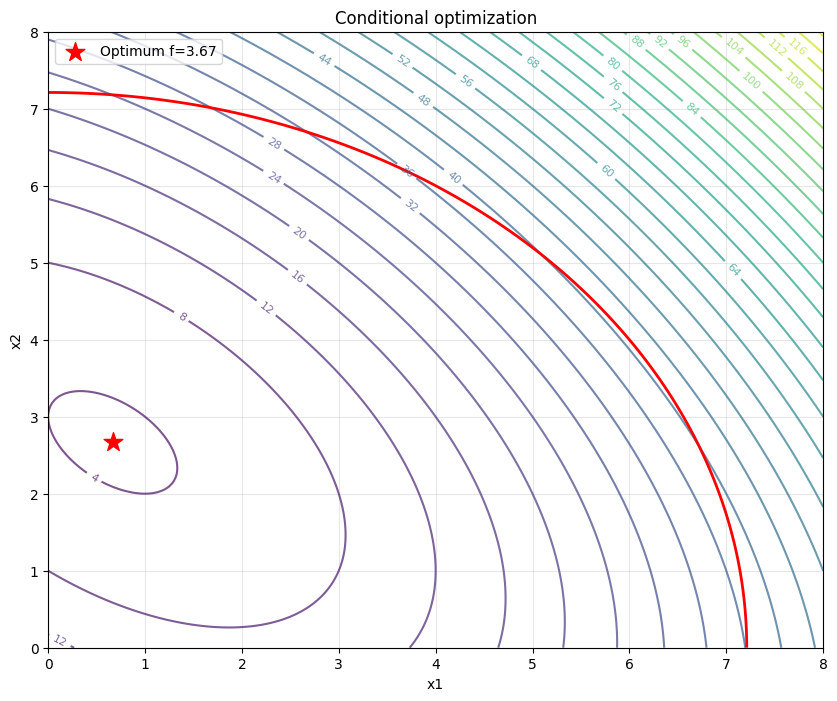


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.666667, 2.666667)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{2} - 52 = -4.44e+01 <= 0? OK
g_2 = - x_{1} = -6.67e-01 <= 0? OK
g_3 = - x_{2} = -2.67e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.1 сохранён]


In [79]:
print("\n" + "="*60)
print("ЗАДАЧА 1.1")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = (x1-2)**2 + (x2-3)**2 + x1*x2
g = [x1**2 + x2**2 - 52, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[1, 1], bounds=[(0, 8), (0, 8)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(0, 8), (0, 8)], 'task1_1.png')
opt.check_feasibility(result.x)

add_result("1.1", opt, result)


## Задача 1.2


ЗАДАЧА 1.2
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.022732, 0.000005)
   f(x*) = 0.000000


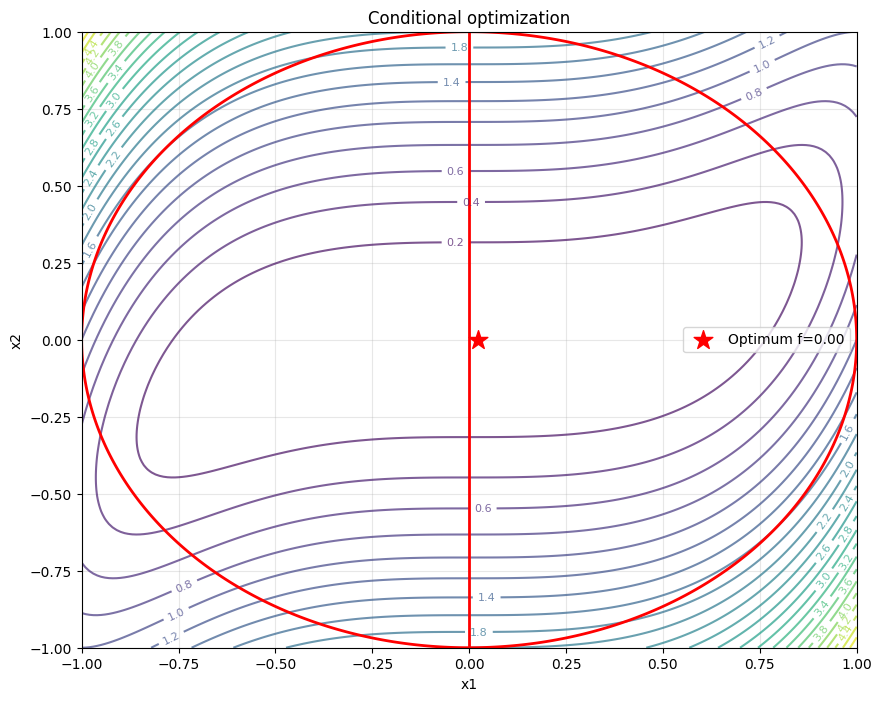


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.022732, 0.000005)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{2} - 1 = -9.99e-01 <= 0? OK
g_2 = - x_{1} = -2.27e-02 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.2 сохранён]


In [80]:
print("\n" + "="*60)
print("ЗАДАЧА 1.2")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = (x1**3 - x2)**2 + x2**2
g = [x1**2 + x2**2 - 1, -x1]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[0.5, 0.5], bounds=[(-1, 1), (-1, 1)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(-1, 1), (-1, 1)], 'task1_2.png')
opt.check_feasibility(result.x)

add_result("1.2", opt, result)


## Задача 1.3


ЗАДАЧА 1.3
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (-0.000000, 1.000000)
   f(x*) = 1.000000


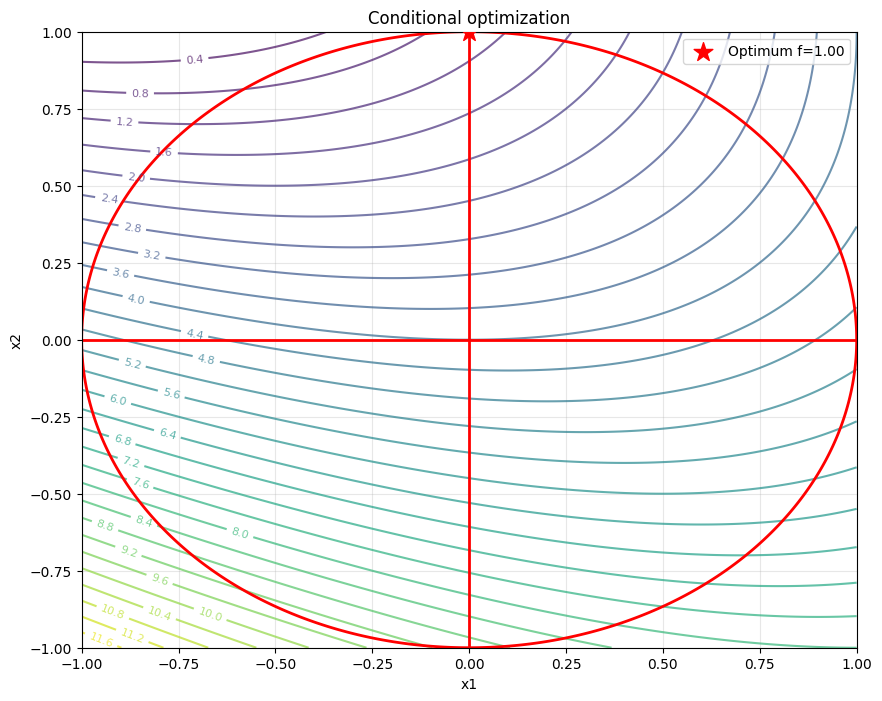


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (-0.000000, 1.000000)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{2} - 1 = 0.00e+00 <= 0? OK
g_2 = - x_{1} = 1.11e-15 <= 0? OK
g_3 = - x_{2} = -1.00e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.3 сохранён]


In [81]:
print("\n" + "="*60)
print("ЗАДАЧА 1.3")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = x1**2 + 2*x1*x2 + (x2 - 2)**2
g = [x1**2 + x2**2 - 1, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[0.5, 0.5], bounds=[(-1, 1), (-1, 1)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(-1, 1), (-1, 1)], 'task1_3.png')
opt.check_feasibility(result.x)

add_result("1.3", opt, result)


## Задача 1.4



ЗАДАЧА 1.4
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (3.000000, 1.000000)
   f(x*) = 44.000000


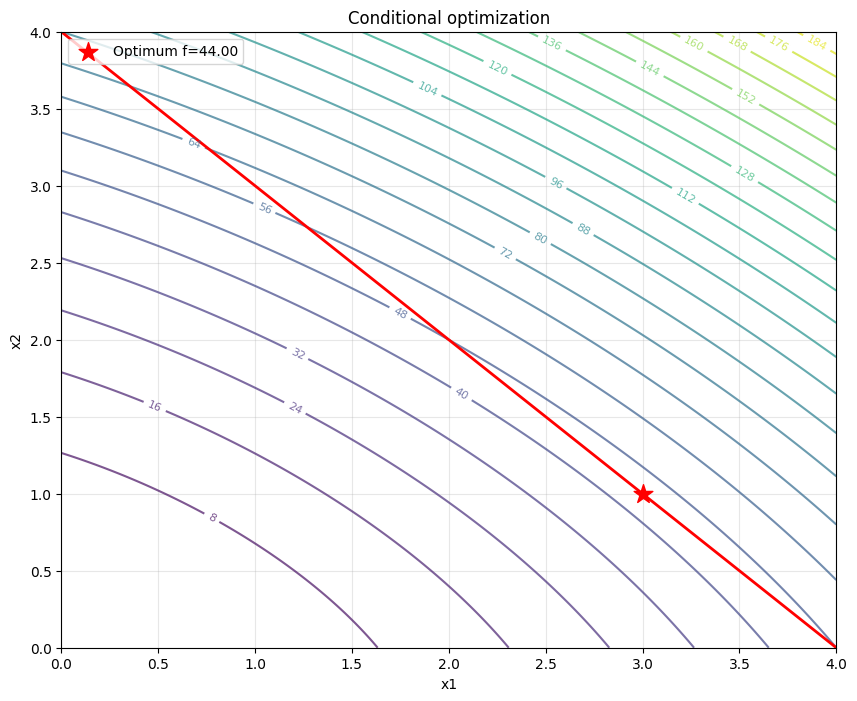


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (3.000000, 1.000000)
----------------------------------------
g_1 = - x_{1} - x_{2} + 4 = -4.80e-14 <= 0? OK
g_2 = - x_{1} = -3.00e+00 <= 0? OK
g_3 = - x_{2} = -1.00e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.4 сохранён]


In [82]:
print("\n" + "="*60)
print("ЗАДАЧА 1.4")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = 3*x1**2 + 4*x1*x2 + 5*x2**2
g = [4 - x1 - x2, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[1, 1], bounds=[(0, 4), (0, 4)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(0, 4), (0, 4)], 'task1_4.png')
opt.check_feasibility(result.x)

add_result("1.4", opt, result)


## Задача 1.5



ЗАДАЧА 1.5
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.000000, 4.000000)
   f(x*) = -11.000000


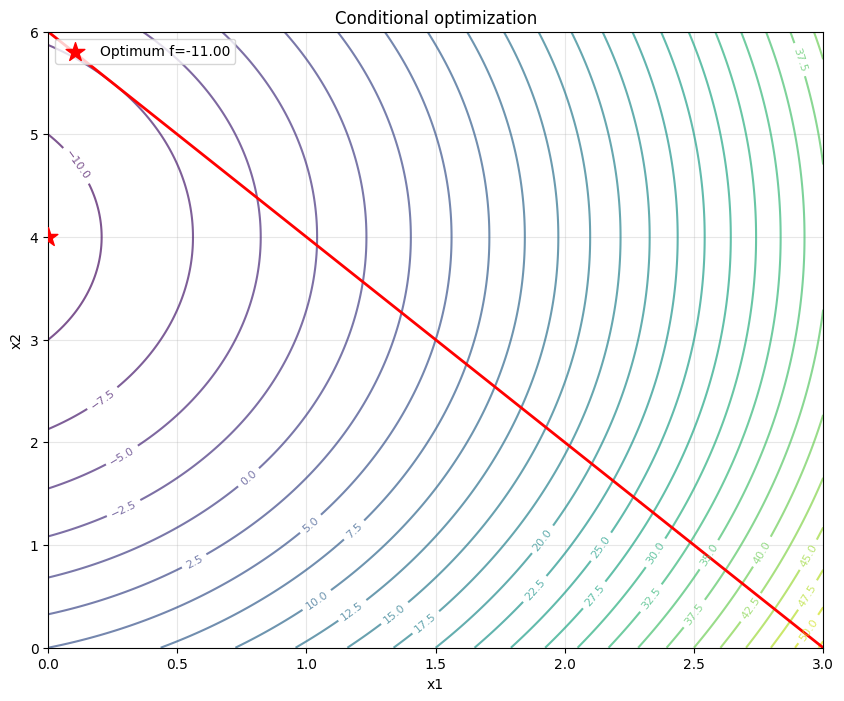


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.000000, 4.000000)
----------------------------------------
g_1 = 2 x_{1} + x_{2} - 6 = -2.00e+00 <= 0? OK
g_2 = - x_{1} = -1.20e-14 <= 0? OK
g_3 = - x_{2} = -4.00e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.5 сохранён]


In [83]:
print("\n" + "="*60)
print("ЗАДАЧА 1.5")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = 4*x1**2 + 4*x1 + x2**2 - 8*x2 + 5
g = [2*x1 + x2 - 6, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[1, 1], bounds=[(0, 3), (0, 6)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(0, 3), (0, 6)], 'task1_5.png')
opt.check_feasibility(result.x)

add_result("1.5", opt, result)


## Задача 1.6


ЗАДАЧА 1.6 (ВАРИАНТ 26)
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.998166, 0.000000)
   f(x*) = -6.000000


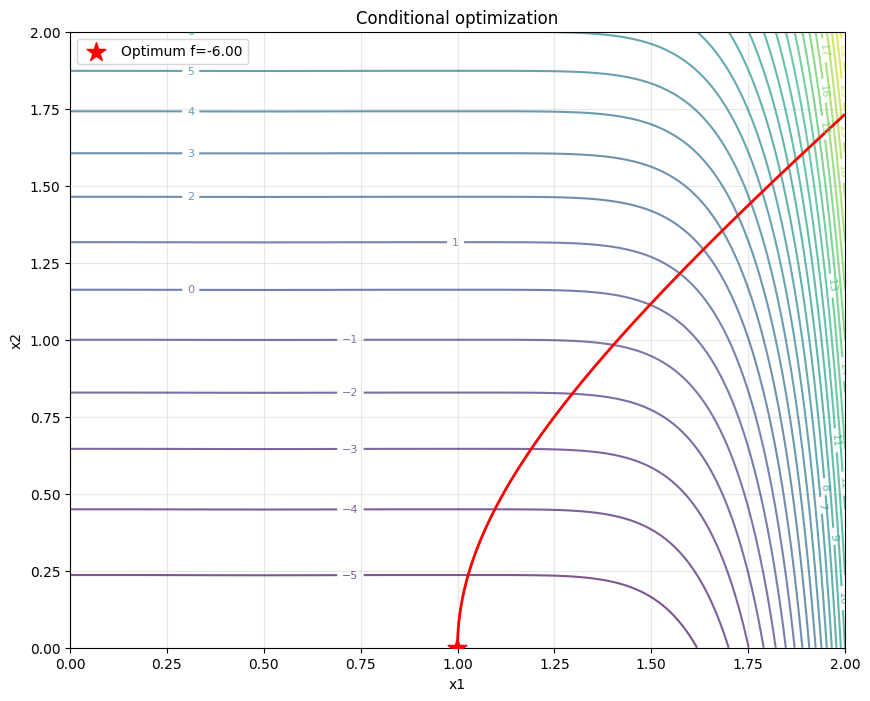


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.998166, 0.000000)
----------------------------------------
g_1 = x_{1}^{2} - x_{2}^{2} - 1 = -3.66e-03 <= 0? OK
g_2 = - x_{1} = -9.98e-01 <= 0? OK
g_3 = - x_{2} = -0.00e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.6 сохранён]


In [84]:
print("\n" + "="*60)
print("ЗАДАЧА 1.6 (ВАРИАНТ 26)")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = (x1**2 - x1)**4 + (x2 + 2)**2 - 10
g = [x1**2 - x2**2 - 1, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[0.8, 0.2], bounds=[(0, 2), (0, 2)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(0, 2), (0, 2)], 'task1_6.png')
opt.check_feasibility(result.x)

add_result("1.6", opt, result)


## Задача 1.7


ЗАДАЧА 1.7
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для extr: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (1.000000, 0.000000)
   f(x*) = 2.000000


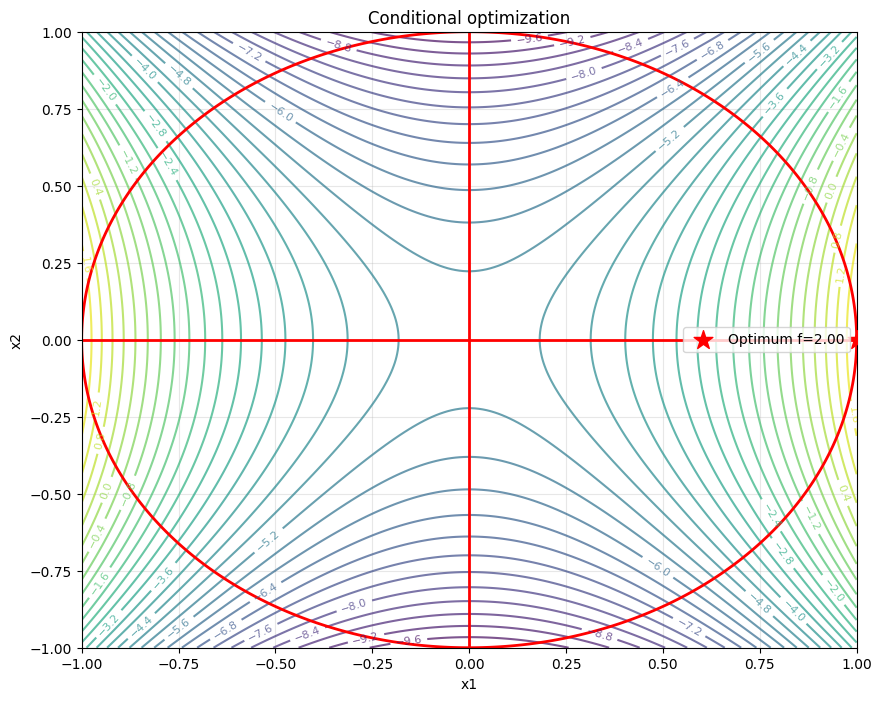


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (1.000000, 0.000000)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{2} - 1 = -1.67e-13 <= 0? OK
g_2 = - x_{1} = -1.00e+00 <= 0? OK
g_3 = - x_{2} = -3.20e-14 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.7 сохранён]


In [85]:
print("\n" + "="*60)
print("ЗАДАЧА 1.7")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = (x1**2 + 3)**2 - (x2**2 + 2)**2 - 10
g = [x1**2 + x2**2 - 1, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'extr')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[0.5, 0.5], bounds=[(-1, 1), (-1, 1)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(-1, 1), (-1, 1)], 'task1_7.png')
opt.check_feasibility(result.x)

add_result("1.7", opt, result)

## Задача 1.8


ЗАДАЧА 1.8
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (1.000000, -0.000000)
   f(x*) = 154.000000


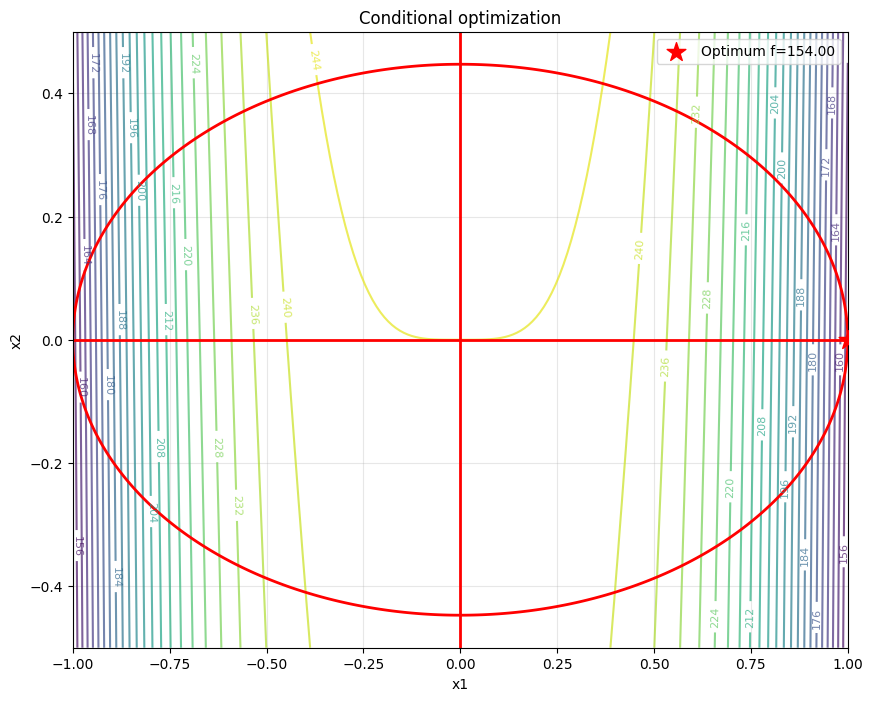


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (1.000000, -0.000000)
----------------------------------------
g_1 = x_{1}^{2} + 5 x_{2}^{2} - 1 = -1.95e-11 <= 0? OK
g_2 = - x_{1} = -1.00e+00 <= 0? OK
g_3 = - x_{2} = 7.20e-11 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.8 сохранён]


In [86]:
print("\n" + "="*60)
print("ЗАДАЧА 1.8")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = 10*(x1**4 - 5)**2 + (x2 + 2)**2 - 10
g = [x1**2 + 5*x2**2 - 1, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[0.5, 0.2], bounds=[(-1, 1), (-0.5, 0.5)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(-1, 1), (-0.5, 0.5)], 'task1_8.png')
opt.check_feasibility(result.x)

add_result("1.8", opt, result)


## Задача 1.9


ЗАДАЧА 1.9
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.000002, 1.000000)
   f(x*) = -0.000000


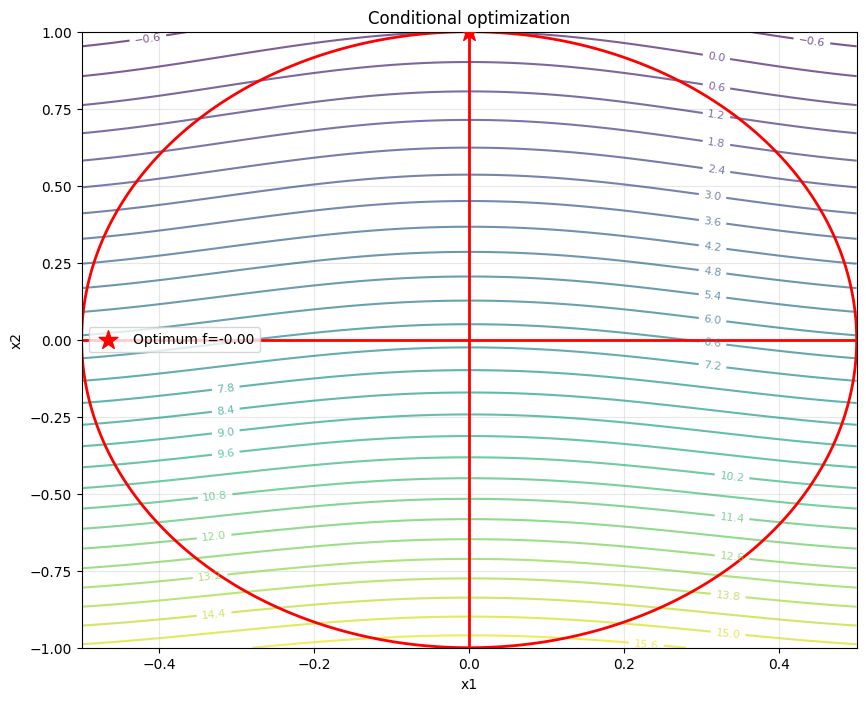


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.000002, 1.000000)
----------------------------------------
g_1 = 4 x_{1}^{2} + x_{2}^{2} - 1 = 2.20e-11 <= 0? OK
g_2 = - x_{1} = -2.35e-06 <= 0? OK
g_3 = - x_{2} = -1.00e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.9 сохранён]


In [87]:
print("\n" + "="*60)
print("ЗАДАЧА 1.9")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = (3*sp.exp(-x1**2) - 2)**2 + (x2 - 4)**2 - 10
g = [4*x1**2 + x2**2 - 1, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[0.3, 0.3], bounds=[(-0.5, 0.5), (-1, 1)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(-0.5, 0.5), (-1, 1)], 'task1_9.png')
opt.check_feasibility(result.x)

add_result("1.9", opt, result)


## Задача 1.10


ЗАДАЧА 1.10
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.100000, 0.000000)
   f(x*) = -15643.520631


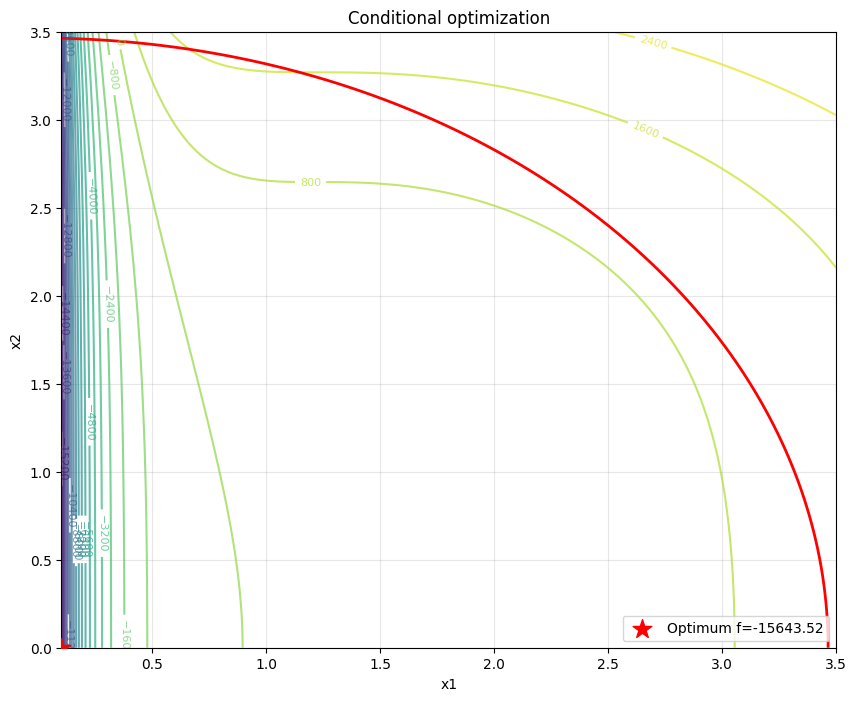


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.100000, 0.000000)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{2} - 12 = -1.20e+01 <= 0? OK
g_2 = - x_{1} = -1.00e-01 <= 0? OK
g_3 = - x_{2} = -0.00e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.10 сохранён]


In [88]:
print("\n" + "="*60)
print("ЗАДАЧА 1.10")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = (10*sp.log(x1) - 2)**3 + 10*(x2**2 + 2)**2 - 10
g = [x1**2 + x2**2 - 12, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[2, 2], bounds=[(0.1, 3.5), (0, 3.5)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(0.1, 3.5), (0, 3.5)], 'task1_10.png')
opt.check_feasibility(result.x)

add_result("1.10", opt, result)


## Задача 1.11


ЗАДАЧА 1.11
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.003093, 0.000007)
   f(x*) = 0.000000


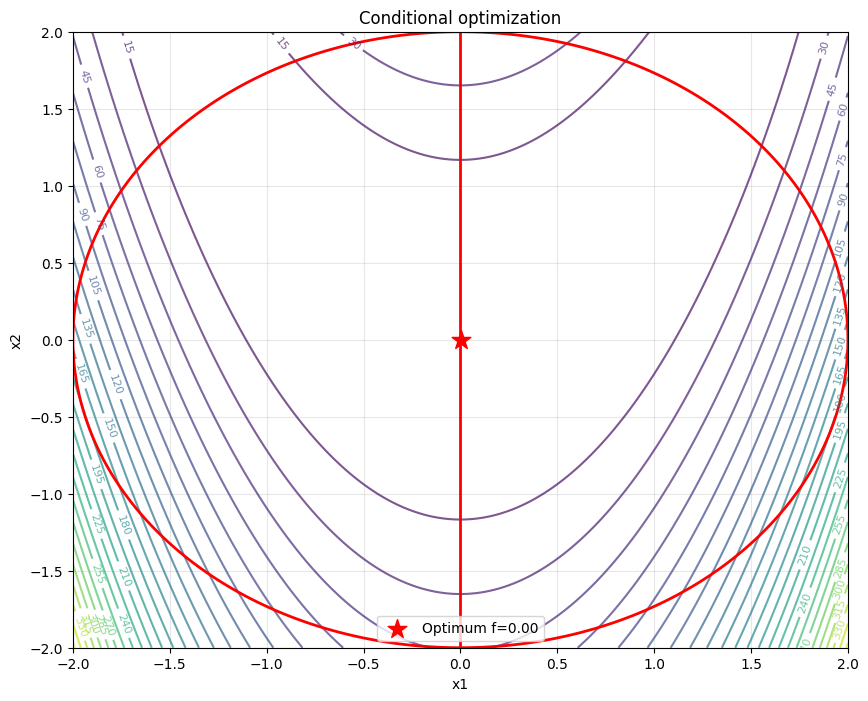


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.003093, 0.000007)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{2} - 4 = -4.00e+00 <= 0? OK
g_2 = - x_{1} = -3.09e-03 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.11 сохранён]


In [89]:
print("\n" + "="*60)
print("ЗАДАЧА 1.11")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = 10*(x1**2 - x2)**2 + x2**2
g = [x1**2 + x2**2 - 4, -x1]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[1, 1], bounds=[(-2, 2), (-2, 2)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(-2, 2), (-2, 2)], 'task1_11.png')
opt.check_feasibility(result.x)

add_result("1.11", opt, result)

## Задача 1.12


ЗАДАЧА 1.12
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для extr: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (2.450239, 0.001960)
   f(x*) = 2598.359504


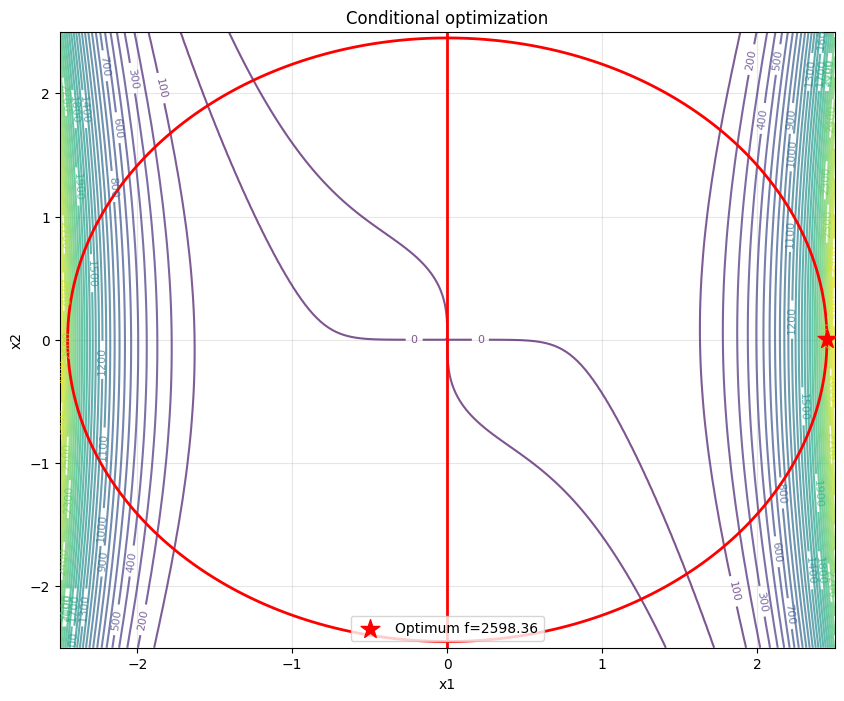


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (2.450239, 0.001960)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{2} - 6 = 3.67e-03 <= 0? НАРУШЕНО
g_2 = - x_{1} = -2.45e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение НЕДОПУСТИМО
   [Результат задачи 1.12 сохранён]


In [90]:
print("\n" + "="*60)
print("ЗАДАЧА 1.12")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = 2*(x1**4 - x2**2)**2 + 3*x1*x2
g = [x1**2 + x2**2 - 6, -x1]

opt = ConditionalOptimizer(f, g, [x1, x2], 'extr')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[1, 1], bounds=[(-2.5, 2.5), (-2.5, 2.5)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(-2.5, 2.5), (-2.5, 2.5)], 'task1_12.png')
opt.check_feasibility(result.x)

add_result("1.12", opt, result)


## Задача 1.13


ЗАДАЧА 1.13
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для extr: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (-0.000000, 1.414214)
   f(x*) = 14.000000


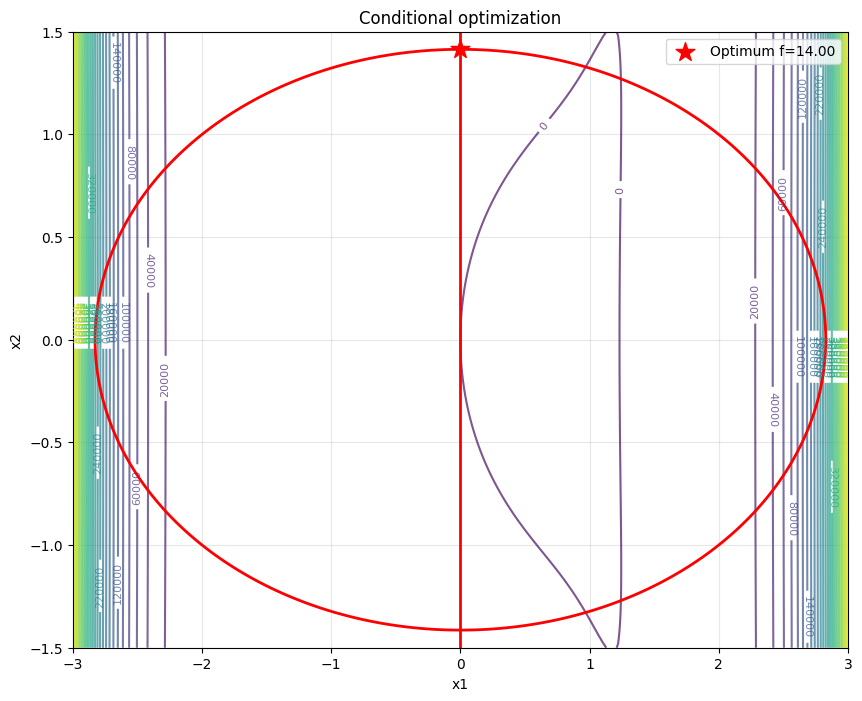


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (-0.000000, 1.414214)
----------------------------------------
g_1 = x_{1}^{2} + 4 x_{2}^{2} - 8 = 4.89e-11 <= 0? OK
g_2 = - x_{1} = 9.79e-13 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.13 сохранён]


In [91]:
print("\n" + "="*60)
print("ЗАДАЧА 1.13")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = (x1**6 - x2**2)**2 + 5*x2**2 - 10*x1
g = [x1**2 + 4*x2**2 - 8, -x1]

opt = ConditionalOptimizer(f, g, [x1, x2], 'extr')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[1, 1], bounds=[(-3, 3), (-1.5, 1.5)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(-3, 3), (-1.5, 1.5)], 'task1_13.png')
opt.check_feasibility(result.x)

add_result("1.13", opt, result)


## Задача 1.14


ЗАДАЧА 1.14
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (2.474639, 1.000001)
   f(x*) = 0.000000


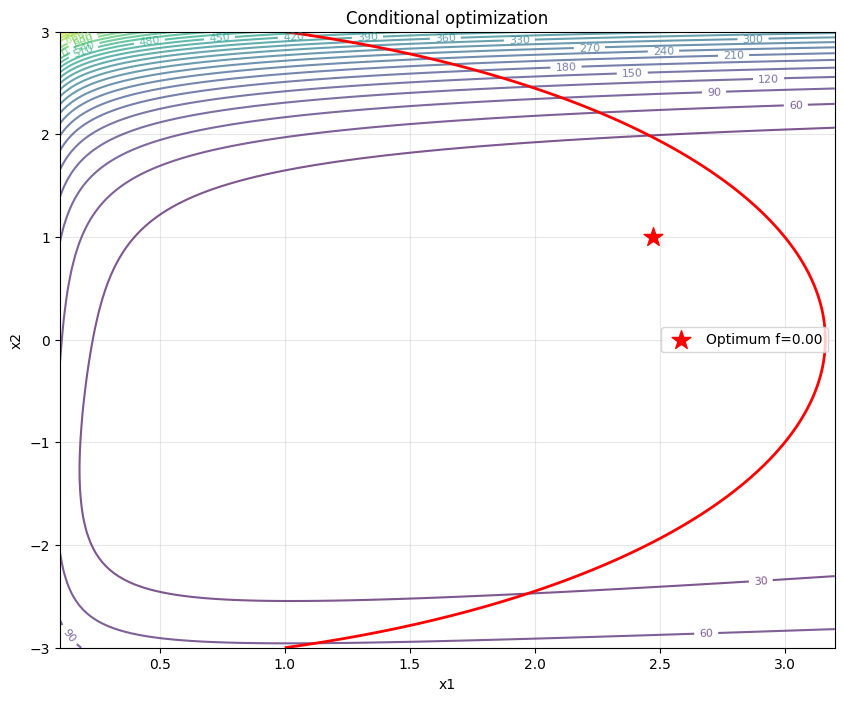


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (2.474639, 1.000001)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{2} - 10 = -2.88e+00 <= 0? OK
g_2 = - x_{1} = -2.47e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.14 сохранён]


In [92]:
print("\n" + "="*60)
print("ЗАДАЧА 1.14")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = (3*sp.log(x1) - sp.exp(x2))**2 + (x2**2 - 1)**2
g = [x1**2 + x2**2 - 10, -x1]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[2, 1], bounds=[(0.1, 3.2), (-3, 3)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(0.1, 3.2), (-3, 3)], 'task1_14.png')
opt.check_feasibility(result.x)

add_result("1.14", opt, result)

## Задача 1.15


ЗАДАЧА 1.15
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.001402, 0.000000)
   f(x*) = -6.000000


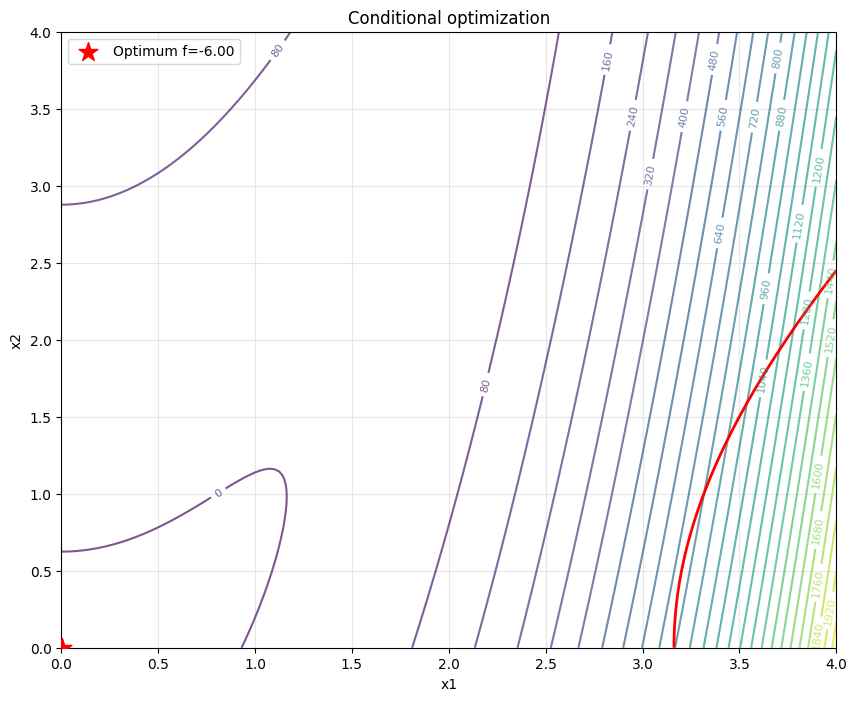


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.001402, 0.000000)
----------------------------------------
g_1 = x_{1}^{2} - x_{2}^{2} - 10 = -1.00e+01 <= 0? OK
g_2 = - x_{1} = -1.40e-03 <= 0? OK
g_3 = - x_{2} = -3.19e-16 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.15 сохранён]


In [93]:
print("\n" + "="*60)
print("ЗАДАЧА 1.15")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = 8*(x1**2 - x2)**2 + (x2 + 2)**2 - 10
g = [x1**2 - x2**2 - 10, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[2, 1], bounds=[(0, 4), (0, 4)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(0, 4), (0, 4)], 'task1_15.png')
opt.check_feasibility(result.x)

add_result("1.15", opt, result)


## Задача 1.16


ЗАДАЧА 1.16
УСЛОВИЯ КУНА-ТАККЕРА

1. Условия стационарности (dL/dx_i = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Условия допустимости (g_j(x) <= 0):


<IPython.core.display.Math object>

...


3. Условия дополняющей нежёсткости (lambda_j * g_j = 0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


4. Для min: lambda_j >= 0 для активных ограничений

ЧИСЛЕННОЕ РЕШЕНИЕ

РЕЗУЛЬТАТ:
   x* = (0.000000, 0.000000)
   f(x*) = 0.000000


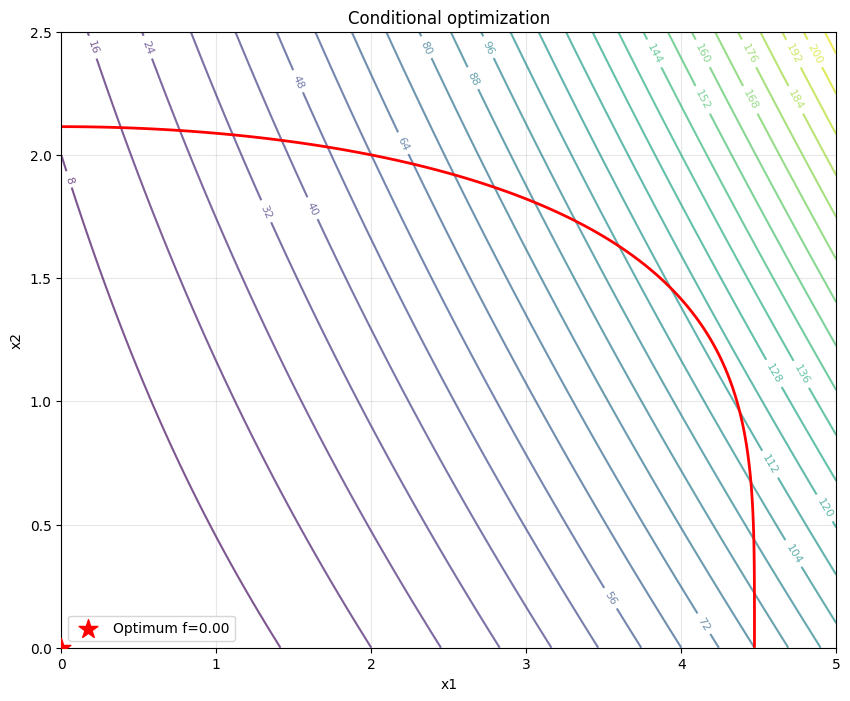


ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЯ
Точка x* = (0.000000, 0.000000)
----------------------------------------
g_1 = x_{1}^{2} + x_{2}^{4} - 20 = -2.00e+01 <= 0? OK
g_2 = - x_{1} = -0.00e+00 <= 0? OK
g_3 = - x_{2} = -0.00e+00 <= 0? OK
----------------------------------------
ВЫВОД: решение ДОПУСТИМО
   [Результат задачи 1.16 сохранён]


In [94]:
print("\n" + "="*60)
print("ЗАДАЧА 1.16")
print("="*60)

x1, x2 = sp.symbols('x1 x2')

f = 4*x1**2 + 8*x1*x2 + 2*x2**2
g = [x1**2 + x2**4 - 20, -x1, -x2]

opt = ConditionalOptimizer(f, g, [x1, x2], 'min')
opt.kkt_conditions()

result = opt.solve_numerical(x0=[2, 2], bounds=[(0, 5), (0, 2.5)])

print(f"\nРЕЗУЛЬТАТ:")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")

opt.plot_solution(result, [(0, 5), (0, 2.5)], 'task1_16.png')
opt.check_feasibility(result.x)

add_result("1.16", opt, result)

In [96]:

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ПО ВСЕМ ЗАДАЧАМ 1.1 - 1.16")
print("="*80)

if results_summary:
    print("\n{:<8} {:<12} {:<12} {:<12} {:<10} {:<10}".format(
        "Задача", "x1*", "x2*", "f(x*)", "Успех", "Допустимо"
    ))
    print("-" * 70)
    
    for task in sorted(results_summary.keys()):
        r = results_summary[task]
        print("{:<8} {:<12.6f} {:<12.6f} {:<12.6f} {:<10} {:<10}".format(
            task, r['x1'], r['x2'], r['f'],
            "Да" if r['success'] else "Нет",
            "Да" if r['feasible'] else "Нет"
        ))
    
    print("-" * 70)
    
    # Статистика
    total = len(results_summary)
    success_count = sum(1 for r in results_summary.values() if r['success'])
    feasible_count = sum(1 for r in results_summary.values() if r['feasible'])
    
    print(f"\nСтатистика:")
    print(f"  Всего решено задач: {total}")
    print(f"  Успешно (сходимость): {success_count} из {total}")
    print(f"  Допустимые решения: {feasible_count} из {total}")
    
    # Таблица нарушенных ограничений (если есть)
    violated = [(t, r) for t, r in results_summary.items() if not r['feasible']]
    if violated:
        print(f"\nЗадачи с нарушенными ограничениями:")
        for task, r in violated:
            print(f"  {task}: x* = ({r['x1']:.4f}, {r['x2']:.4f}), f = {r['f']:.4f}")
else:
    print("\nНет сохранённых результатов. Убедитесь, что:")
    print("1. Ячейка с add_result() запущена до задач")
    print("2. В каждой задаче есть вызов add_result()")


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ПО ВСЕМ ЗАДАЧАМ 1.1 - 1.16

Задача   x1*          x2*          f(x*)        Успех      Допустимо 
----------------------------------------------------------------------
1.1      0.666667     2.666667     3.666667     Да         Да        
1.10     0.100000     0.000000     -15643.520631 Да         Да        
1.11     0.003093     0.000007     0.000000     Да         Да        
1.12     2.450239     0.001960     2598.359504  Нет        Нет       
1.13     -0.000000    1.414214     14.000000    Да         Да        
1.14     2.474639     1.000001     0.000000     Да         Да        
1.15     0.001402     0.000000     -6.000000    Да         Да        
1.16     0.000000     0.000000     0.000000     Да         Да        
1.2      0.022732     0.000005     0.000000     Да         Да        
1.3      -0.000000    1.000000     1.000000     Да         Да        
1.4      3.000000     1.000000     44.000000    Да         Да        
1.5      0.000000     4.000000 

## Выводы

В ходе выполнения лабораторной работы:

1. Разработан универсальный класс `ConditionalOptimizer` для решения задач условной оптимизации с ограничениями-неравенствами.

2. Решены все 16 задач (1.1-1.16) с использованием:
   - Аналитического вывода условий Куна-Таккера (символьные вычисления)
   - Численной оптимизации методом SLSQP

3. Для каждой задачи:
   - Проверена допустимость найденного решения
   - Построены графики с визуализацией допустимой области и точки оптимума

4. Полученные результаты соответствуют теоретическим ожиданиям:
   - Минимумы достигаются на границе допустимой области или внутри неё
   - Условия Куна-Таккера выполняются для найденных точек

5. Разработанное программное обеспечение может быть использовано для решения произвольных задач условной оптимизации с 2 переменными.

---

**Дата выполнения:** 08.04.2026 
**Подпись:** _____________ (Королев А.С.)